## Mahdi-URLLC

In [ ]:
import re

def xg_extract_avg_end2end_with_prediction(log_file):
    # Regex patterns
    pattern = re.compile(
        r"Predicted class:.*?end2end=([\d.]+)\s*ms",
        re.IGNORECASE
    )

    end2end_values = []

    with open(log_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                end2end_values.append(float(match.group(1)))

    return sum(end2end_values) / len(end2end_values) if end2end_values else 0.0


def tr_extract_end2end_with_total_stage_gt_zero(log_file):
    pattern = re.compile(
        r"total_stage=([\d.]+)\s*ms.*?end2end=([\d.]+)\s*ms",
        re.IGNORECASE
    )

    end2end_values = []

    with open(log_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                total_stage = float(match.group(1))
                end2end = float(match.group(2))

                if total_stage > 0:
                    end2end_values.append(end2end)

    return sum(end2end_values) / len(end2end_values) if end2end_values else 0.0

# Path to your log file
log_file_mono4 = "/content/logs-tractor-mono-mahdi-embb-4.txt"
log_file_xgboost4 = "/content/logs-xgboost-mahdi-embb-4.txt"

log_file_mono8 = "/content/logs-tractor-mono-mahdi-embb-8.txt"
log_file_xgboost8 = "/content/logs-xgboost-mahdi-embb-8.txt"

log_file_mono16 = "/content/logs-tractor-mono-mahdi-embb-16.txt"
log_file_xgboost16 = "/content/logs-xgboost-mahdi-embb-16.txt"

log_file_mono32 = "/content/logs-tractor-mono-mahdi-embb-32.txt"
log_file_xgboost32 = "/content/logs-xgboost-mahdi-embb-32.txt"

print("T = 4")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono4))
print("xgboost: ", xg_extract_avg_end2end_with_prediction(log_file_xgboost4))

print("T = 8")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono8))
print("xgboost: ", xg_extract_avg_end2end_with_prediction(log_file_xgboost8))

print("T = 16")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono16))
print("xgboost: ", xg_extract_avg_end2end_with_prediction(log_file_xgboost16))

print("T = 32")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono32))
print("xgboost: ", xg_extract_avg_end2end_with_prediction(log_file_xgboost32))

T = 4
tractor:  2.0600694444444443
xgboost:  2.9117598253275108
T = 8
tractor:  2.5697535211267604
xgboost:  1.4696898148148148
T = 16
tractor:  3.7992988929889293
xgboost:  2.195417525773196
T = 32
tractor:  7.2278
xgboost:  1.3161497584541062


In [ ]:
import re
from collections import Counter

def extract_predicted_classes(log_file):
  # Regex to capture predicted class
  pattern = re.compile(r"Predicted class:\s*([A-Za-z0-9_]+)")

  predicted_classes = []

  with open(log_file, "r") as f:
      for line in f:
          match = pattern.search(line)
          if match:
              predicted_classes.append(match.group(1))

  # Count occurrences
  class_counts = Counter(predicted_classes)
  return list(class_counts.items())


def acc_percentage(data, label):
    """
    data: list of (class, count)
    label: class name (string)
    returns percentage of the label
    """
    total = sum(count for _, count in data)
    label_count = next((count for cls, count in data if cls == label), 0)

    if total == 0:
        return 0.0

    return (label_count / total) * 100

# Path to your log file
log_file_mono4 = "/content/logs-tractor-mono-mahdi-embb-4.txt"
log_file_xgboost4 = "/content/logs-xgboost-mahdi-embb-4.txt"

log_file_mono8 = "/content/logs-tractor-mono-mahdi-embb-8.txt"
log_file_xgboost8 = "/content/logs-xgboost-mahdi-embb-8.txt"

log_file_mono16 = "/content/logs-tractor-mono-mahdi-embb-16.txt"
log_file_xgboost16 = "/content/logs-xgboost-mahdi-embb-16.txt"

log_file_mono32 = "/content/logs-tractor-mono-mahdi-embb-32.txt"
log_file_xgboost32 = "/content/logs-xgboost-mahdi-embb-32.txt"

# Extract predicted classes from both log files
class_counts_mono4 = extract_predicted_classes(log_file_mono4)
class_counts_xgboost4 = extract_predicted_classes(log_file_xgboost4)

print(class_counts_mono4)
print(class_counts_xgboost4)

print("T = 4")
print("tractor: ", acc_percentage(class_counts_mono4, "eMBB"))
print("xgboost: ", acc_percentage(class_counts_xgboost4, "eMBB"))

class_counts_mono8 = extract_predicted_classes(log_file_mono8)
class_counts_xgboost8 = extract_predicted_classes(log_file_xgboost8)

print(class_counts_mono8)
print(class_counts_xgboost8)

print("T = 8")
print("tractor: ", acc_percentage(class_counts_mono8, "eMBB"))
print("xgboost: ", acc_percentage(class_counts_xgboost8, "eMBB"))

class_counts_mono16 = extract_predicted_classes(log_file_mono16)
class_counts_xgboost16 = extract_predicted_classes(log_file_xgboost16)

print(class_counts_mono16)
print(class_counts_xgboost16)

print("T = 16")
print("tractor: ", acc_percentage(class_counts_mono16, "eMBB"))
print("xgboost: ", acc_percentage(class_counts_xgboost16, "eMBB"))

class_counts_mono32 = extract_predicted_classes(log_file_mono32)
class_counts_xgboost32 = extract_predicted_classes(log_file_xgboost32)

print(class_counts_mono32)
print(class_counts_xgboost32)

print("T = 32")
print("tractor: ", acc_percentage(class_counts_mono32, "eMBB"))
print("xgboost: ", acc_percentage(class_counts_xgboost32, "eMBB"))

[('UNKNOWN', 288)]
[('eMBB', 229)]
T = 4
tractor:  0.0
xgboost:  100.0
[('mMTC', 284)]
[('eMBB', 216)]
T = 8
tractor:  0.0
xgboost:  100.0
[('mMTC', 271)]
[('eMBB', 194)]
T = 16
tractor:  0.0
xgboost:  100.0
[('eMBB', 250)]
[('eMBB', 207)]
T = 32
tractor:  100.0
xgboost:  100.0


## UNICORN

In [ ]:
import re

def xg_extract_avg_end2end_with_prediction(log_file):
    # Regex patterns
    pattern = re.compile(
        r"Predicted class:.*?end2end=([\d.]+)\s*ms",
        re.IGNORECASE
    )

    end2end_values = []

    with open(log_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                end2end_values.append(float(match.group(1)))

    return sum(end2end_values) / len(end2end_values) if end2end_values else 0.0


def tr_extract_end2end_with_total_stage_gt_zero(log_file):
    pattern = re.compile(
        r"total_stage=([\d.]+)\s*ms.*?end2end=([\d.]+)\s*ms",
        re.IGNORECASE
    )

    end2end_values = []

    with open(log_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                total_stage = float(match.group(1))
                end2end = float(match.group(2))

                if total_stage > 0:
                    end2end_values.append(end2end)

    return sum(end2end_values) / len(end2end_values) if end2end_values else 0.0

# Path to your log file
log_file_mono4 = "/content/logs-tractor-mono.txt"
log_file_xgboost4 = "/content/logs-xgboost.txt"

log_file_mono8 = "/content/logs-tractor-mono-8.txt"
log_file_xgboost8 = "/content/logs-xgboost-8.txt"

log_file_mono16 = "/content/logs-tractor-mono-16.txt"
log_file_xgboost16 = "/content/logs-xgboost-16.txt"

log_file_mono32 = "/content/logs-tractor-mono-32.txt"
log_file_xgboost32 = "/content/logs-xgboost-32.txt"

print("T = 4 ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono4))
print("T = 4 ", xg_extract_avg_end2end_with_prediction(log_file_xgboost4))

print("T = 8 ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono8))
print("T = 8 ", xg_extract_avg_end2end_with_prediction(log_file_xgboost8))

print("T = 16 ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono16))
print("T = 16 ", xg_extract_avg_end2end_with_prediction(log_file_xgboost16))

print("T = 32 ", tr_extract_end2end_with_total_stage_gt_zero(log_file_mono32))
print("T = 32 ", xg_extract_avg_end2end_with_prediction(log_file_xgboost32))

T = 32  7.702314049586777
T = 32  1.2004285714285714


In [ ]:
import re
from collections import Counter

def extract_predicted_classes(log_file):
  # Regex to capture predicted class
  pattern = re.compile(r"Predicted class:\s*([A-Za-z0-9_]+)")

  predicted_classes = []

  with open(log_file, "r") as f:
      for line in f:
          match = pattern.search(line)
          if match:
              predicted_classes.append(match.group(1))

  # Count occurrences
  class_counts = Counter(predicted_classes)
  return list(class_counts.items())


def acc_percentage(data, label):
    """
    data: list of (class, count)
    label: class name (string)
    returns percentage of the label
    """
    total = sum(count for _, count in data)
    label_count = next((count for cls, count in data if cls == label), 0)

    if total == 0:
        return 0.0

    return (label_count / total) * 100

# Path to your log file
log_file_mono4 = "/content/logs-tractor-mono.txt"
log_file_xgboost4 = "/content/logs-xgboost.txt"

log_file_mono8 = "/content/logs-tractor-mono-8.txt"
log_file_xgboost8 = "/content/logs-xgboost-8.txt"

log_file_mono16 = "/content/logs-tractor-mono-16.txt"
log_file_xgboost16 = "/content/logs-xgboost-16.txt"

log_file_mono32 = "/content/logs-tractor-mono-32.txt"
log_file_xgboost32 = "/content/logs-xgboost-32.txt"

# Extract predicted classes from both log files
# class_counts_mono4 = extract_predicted_classes(log_file_mono4)
# class_counts_xgboost4 = extract_predicted_classes(log_file_xgboost4)

# print(class_counts_mono4)
# print(class_counts_xgboost4)

# print("T = 4 ", acc_percentage(class_counts_mono4, "URLLC"))
# print("T = 4 ", acc_percentage(class_counts_xgboost4, "URLLC"))

# class_counts_mono8 = extract_predicted_classes(log_file_mono8)
# class_counts_xgboost8 = extract_predicted_classes(log_file_xgboost8)

# print(class_counts_mono8)
# print(class_counts_xgboost8)

# print("T = 8 ", acc_percentage(class_counts_mono8, "URLLC"))
# print("T = 8 ", acc_percentage(class_counts_xgboost8, "URLLC"))

# class_counts_mono16 = extract_predicted_classes(log_file_mono16)
# class_counts_xgboost16 = extract_predicted_classes(log_file_xgboost16)

# print(class_counts_mono16)
# print(class_counts_xgboost16)

# print("T = 16 ", acc_percentage(class_counts_mono16, "URLLC"))
# print("T = 16 ", acc_percentage(class_counts_xgboost16, "URLLC"))

class_counts_mono32 = extract_predicted_classes(log_file_mono32)
class_counts_xgboost32 = extract_predicted_classes(log_file_xgboost32)

print(class_counts_mono32)
print(class_counts_xgboost32)

print("T = 32 ", acc_percentage(class_counts_mono32, "URLLC"))
print("T = 32 ", acc_percentage(class_counts_xgboost32, "URLLC"))

[('URLLC', 121)]
[('mMTC', 9), ('URLLC', 222)]
T = 32  100.0
T = 32  96.1038961038961


## UNICORN-Microservice-Latency

In [ ]:
import re

def xg_extract_avg_end2end_with_prediction(log_file):
    # Regex patterns
    pattern = re.compile(
        r"Predicted class:.*?end2end=([\d.]+)\s*ms",
        re.IGNORECASE
    )

    end2end_values = []

    with open(log_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                end2end_values.append(float(match.group(1)))

    return sum(end2end_values) / len(end2end_values) if end2end_values else 0.0


def tr_extract_end2end_with_total_stage_gt_zero(log_file):
    pattern = re.compile(
        r"total_stage=([\d.]+)\s*ms.*?end2end=([\d.]+)\s*ms",
        re.IGNORECASE
    )

    end2end_values = []

    with open(log_file, "r") as f:
        for line in f:
            match = pattern.search(line)
            if match:
                total_stage = float(match.group(1))
                end2end = float(match.group(2))

                if total_stage > 0:
                    end2end_values.append(end2end)

    return sum(end2end_values) / len(end2end_values) if end2end_values else 0.0

# Path to your log file
log_file_micro4 = "/content/logs-tractor-micro-4.txt"

log_file_micro8 = "/content/logs-tractor-micro-8.txt"

log_file_micro16 = "/content/logs-tractor-micro-16.txt"

log_file_micro32 = "/content/logs-tractor-micro-32.txt"

print("T = 4")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_micro4))

print("T = 8")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_micro8))

print("T = 16")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_micro16))

print("T = 32")
print("tractor: ", tr_extract_end2end_with_total_stage_gt_zero(log_file_micro32))

T = 4
tractor:  15.243948497854078
T = 8
tractor:  17.048436578171092
T = 16
tractor:  17.59877887788779
T = 32
tractor:  20.131735294117647


## Plots

In [3]:
import matplotlib.font_manager
fonts = [f.name for f in matplotlib.font_manager.fontManager.ttflist]
print('Times New Roman' in fonts)

False


findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: Generic family 'serif' not found because none of the following families were found: Times New Roman
findfont: 

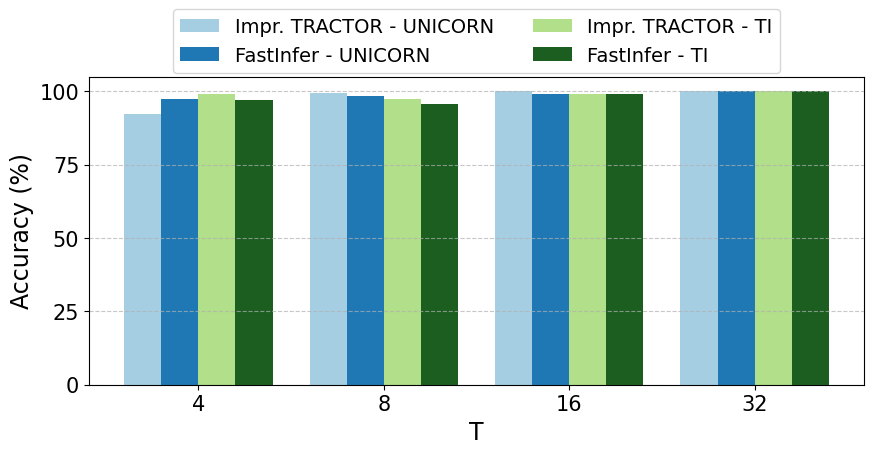

In [2]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ==========================================================
# Font settings
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman']
plt.rcParams['font.size'] = 20

# Font sizes for different elements
LABEL_SIZE = 17
TICK_SIZE = 15
LEGEND_SIZE = 14

# ==========================================================
# Configuration
# ==========================================================

log_file = "/home/lapdk/workspace/oai-v210/tractor/accuracy"

# Color-blind safe (Okabe–Ito palette)
COLORS = {
    # URLLC-UNICORN (blue family)
    "UNICORN-Tractor": "#A6CEE3",   # light blue (Tractor)
    "UNICORN-XGBoost": "#1F78B4",   # dark blue (XGBoost)

    # URLLC-Mahdi (green family)
    "Mahdi-Tractor":   "#B2DF8A",   # light green (Tractor)
    "Mahdi-XGBoost":   "#1B5E20"    # dark green (XGBoost)
}

# ==========================================================
# Read log file
# ==========================================================

with open(log_file, "r") as f:
    lines = f.readlines()

# ==========================================================
# Parse data
# ==========================================================

data = defaultdict(lambda: {
    "T": [],
    "tractor": [],
    "xgboost": []
})

current_dataset = None

for line in lines:
    line = line.strip()

    if line and not line.startswith(("T =", "tractor", "xgboost")):
        current_dataset = line

    elif line.startswith("T ="):
        T_val = int(re.findall(r"\d+", line)[0])
        data[current_dataset]["T"].append(T_val)

    elif line.startswith("tractor"):
        data[current_dataset]["tractor"].append(float(line.split(":")[1]))

    elif line.startswith("xgboost"):
        data[current_dataset]["xgboost"].append(float(line.split(":")[1]))

# ==========================================================
# Plot: URLLC (UNICORN + Mahdi) -> 4 bars per T
# ==========================================================

T = data["URLLC-UNICORN"]["T"]
x = np.arange(len(T))
bar_width = 0.2

plt.figure(figsize=(10, 4))

plt.bar(
    x - 1.5 * bar_width,
    data["URLLC-UNICORN"]["tractor"],
    bar_width,
    label="Impr. TRACTOR - UNICORN",
    color=COLORS["UNICORN-Tractor"]
)

plt.bar(
    x - 0.5 * bar_width,
    data["URLLC-UNICORN"]["xgboost"],
    bar_width,
    label="FastInfer - UNICORN",
    color=COLORS["UNICORN-XGBoost"]
)

plt.bar(
    x + 0.5 * bar_width,
    data["URLLC-Mahdi"]["tractor"],
    bar_width,
    label="Impr. TRACTOR - TI",
    color=COLORS["Mahdi-Tractor"]
)

plt.bar(
    x + 1.5 * bar_width,
    data["URLLC-Mahdi"]["xgboost"],
    bar_width,
    label="FastInfer - TI",
    color=COLORS["Mahdi-XGBoost"]
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

plt.xlabel("T", fontsize=LABEL_SIZE)
plt.ylabel("Accuracy (%)", fontsize=LABEL_SIZE)
# plt.title("URLLC Accuracy Comparison")
plt.xticks(x, T, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.ylim(0, 105)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.legend(
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.25),
    fontsize=LEGEND_SIZE
)

plt.savefig("urllc_acc.pdf", dpi=300, bbox_inches="tight")
plt.show()

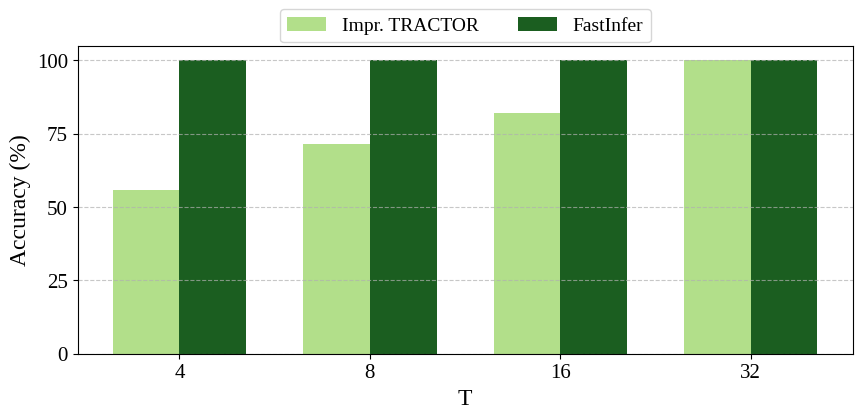

In [5]:
# ==========================================================
# Plot 2: eMBB (Mahdi)
# ==========================================================

T = data["eMBB-Mahdi"]["T"]
x = np.arange(len(T))
bar_width = 0.35

plt.figure(figsize=(10, 4))

plt.bar(x - bar_width/2, data["eMBB-Mahdi"]["tractor"],
        bar_width, label="Impr. TRACTOR", color=COLORS["Mahdi-Tractor"])
plt.bar(x + bar_width/2, data["eMBB-Mahdi"]["xgboost"],
        bar_width, label="FastInfer", color=COLORS["Mahdi-XGBoost"])

plt.xlabel("T", fontsize=LABEL_SIZE)
plt.ylabel("Accuracy (%)", fontsize=LABEL_SIZE)
# plt.title("eMBB Accuracy Comparison")
plt.xticks(x, T, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.ylim(0, 105)
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.legend(
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.15),
    fontsize=LEGEND_SIZE
)
plt.savefig("embb_acc.pdf", dpi=300, bbox_inches="tight")
plt.show()

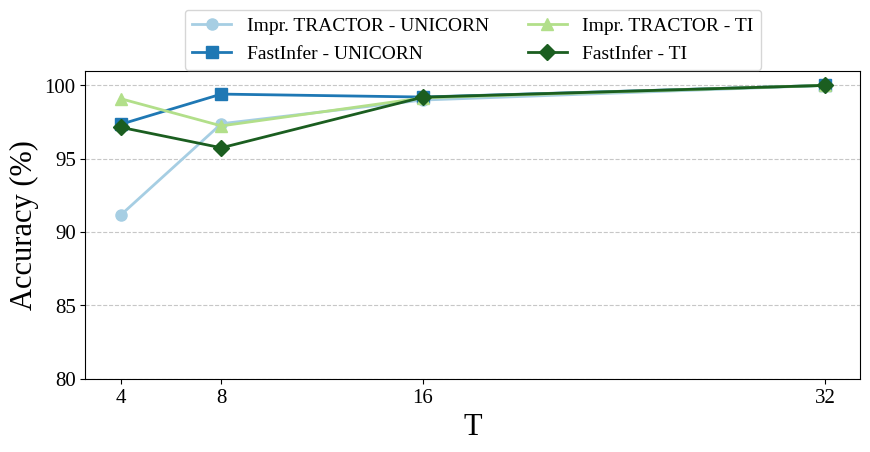

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ==========================================================
# Font settings
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif']
plt.rcParams['font.size'] = 20

# Font sizes for different elements
LABEL_SIZE = 22
TICK_SIZE = 15
LEGEND_SIZE = 14

# ==========================================================
# Configuration
# ==========================================================

log_file = "/content/accuracy"

# Color-blind safe (Okabe–Ito palette)
COLORS = {
    # URLLC-UNICORN (blue family)
    "UNICORN-Tractor": "#A6CEE3",   # light blue (Tractor)
    "UNICORN-XGBoost": "#1F78B4",   # dark blue (XGBoost)

    # URLLC-Mahdi (green family)
    "Mahdi-Tractor":   "#B2DF8A",   # light green (Tractor)
    "Mahdi-XGBoost":   "#1B5E20"    # dark green (XGBoost)
}

# Markers for line plot
MARKERS = {
    "UNICORN-Tractor": "o",
    "UNICORN-XGBoost": "s",
    "Mahdi-Tractor": "^",
    "Mahdi-XGBoost": "D"
}

# ==========================================================
# Read log file
# ==========================================================

with open(log_file, "r") as f:
    lines = f.readlines()

# ==========================================================
# Parse data
# ==========================================================

data = defaultdict(lambda: {
    "T": [],
    "tractor": [],
    "xgboost": []
})

current_dataset = None

for line in lines:
    line = line.strip()

    if line and not line.startswith(("T =", "tractor", "xgboost")):
        current_dataset = line

    elif line.startswith("T ="):
        T_val = int(re.findall(r"\d+", line)[0])
        data[current_dataset]["T"].append(T_val)

    elif line.startswith("tractor"):
        data[current_dataset]["tractor"].append(float(line.split(":")[1]))

    elif line.startswith("xgboost"):
        data[current_dataset]["xgboost"].append(float(line.split(":")[1]))

# ==========================================================
# Plot: URLLC (UNICORN + Mahdi) -> 4 lines
# ==========================================================

T = data["URLLC-UNICORN"]["T"]

plt.figure(figsize=(10, 4))

plt.plot(
    T,
    data["URLLC-UNICORN"]["tractor"],
    label="Impr. TRACTOR - UNICORN",
    color=COLORS["UNICORN-Tractor"],
    marker=MARKERS["UNICORN-Tractor"],
    linewidth=2,
    markersize=8
)

plt.plot(
    T,
    data["URLLC-UNICORN"]["xgboost"],
    label="FastInfer - UNICORN",
    color=COLORS["UNICORN-XGBoost"],
    marker=MARKERS["UNICORN-XGBoost"],
    linewidth=2,
    markersize=8
)

plt.plot(
    T,
    data["URLLC-Mahdi"]["tractor"],
    label="Impr. TRACTOR - TI",
    color=COLORS["Mahdi-Tractor"],
    marker=MARKERS["Mahdi-Tractor"],
    linewidth=2,
    markersize=8
)

plt.plot(
    T,
    data["URLLC-Mahdi"]["xgboost"],
    label="FastInfer - TI",
    color=COLORS["Mahdi-XGBoost"],
    marker=MARKERS["Mahdi-XGBoost"],
    linewidth=2,
    markersize=8
)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

plt.xlabel("T", fontsize=LABEL_SIZE)
plt.ylabel("Accuracy (%)", fontsize=LABEL_SIZE)
# plt.title("URLLC Accuracy Comparison")
plt.xticks(T, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.ylim(80, 101)

plt.grid(axis="y", linestyle="--", alpha=0.7)

plt.legend(
    ncol=2,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.23),
    fontsize=LEGEND_SIZE
)

plt.savefig("urllc_acc.pdf", dpi=300, bbox_inches="tight")
plt.show()

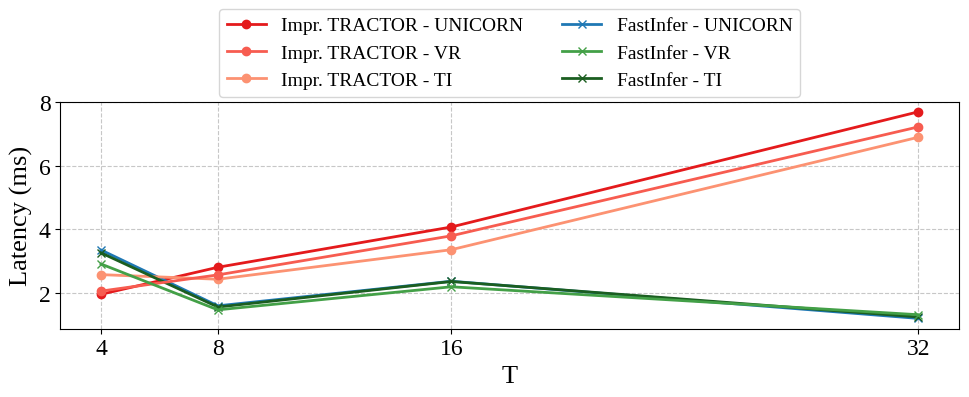

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ==========================================================
# Font settings
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif']
plt.rcParams['font.size'] = 17

# Font sizes for different elements
LABEL_SIZE = 19
TICK_SIZE = 17
LEGEND_SIZE = 14

# ==========================================================
# Configuration
# ==========================================================

log_file = "/content/avg_latency_mono"

# Colors
COLORS = {
    # XGBoost lines (emphasized, good)
    "UNICORN-XGBoost": "#1F78B4",   # blue
    "Mahdi-XGBoost":   "#1B5E20",   # dark green

    # Tractor lines (bad → red)
    "UNICORN-Tractor": "#E41A1C",    # strong red
    "Mahdi-Tractor":   "#FC9272"     # lighter red for contrast
}

# Markers
MARKERS = {
    "Tractor": "o",
    "XGBoost": "x"
}

# ==========================================================
# Read log file
# ==========================================================

with open(log_file, "r") as f:
    lines = f.readlines()

# ==========================================================
# Parse data
# ==========================================================

data = defaultdict(lambda: {
    "T": [],
    "tractor": [],
    "xgboost": []
})

current_dataset = None

for line in lines:
    line = line.strip()

    if line and not line.startswith(("T =", "tractor", "xgboost")):
        current_dataset = line

    elif line.startswith("T ="):
        T_val = int(re.findall(r"\d+", line)[0])
        data[current_dataset]["T"].append(T_val)

    elif line.startswith("tractor"):
        data[current_dataset]["tractor"].append(float(line.split(":")[1]))

    elif line.startswith("xgboost"):
        data[current_dataset]["xgboost"].append(float(line.split(":")[1]))

# ==========================================================
# Plot: Line plot for all datasets
# ==========================================================

plt.figure(figsize=(10, 5))

# URLLC-UNICORN
T = data["URLLC-UNICORN"]["T"]
plt.plot(T, data["URLLC-UNICORN"]["tractor"],
         label="Impr. TRACTOR - UNICORN",
         color=COLORS["UNICORN-Tractor"],
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data["URLLC-UNICORN"]["xgboost"],
         label="FastInfer - UNICORN",
         color=COLORS["UNICORN-XGBoost"],
         marker=MARKERS["XGBoost"],
         linewidth=2)

# URLLC-Mahdi
T = data["URLLC-Mahdi"]["T"]
plt.plot(T, data["URLLC-Mahdi"]["tractor"],
         label="Impr. TRACTOR - TI",
         color=COLORS["Mahdi-Tractor"],
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data["URLLC-Mahdi"]["xgboost"],
         label="FastInfer - TI",
         color=COLORS["Mahdi-XGBoost"],
         marker=MARKERS["XGBoost"],
         linewidth=2)

# eMBB-Mahdi
T = data["eMBB-Mahdi"]["T"]
plt.plot(T, data["eMBB-Mahdi"]["tractor"],
         label="Impr. TRACTOR - VR",
         color="#F75C50",
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data["eMBB-Mahdi"]["xgboost"],
         label="FastInfer - VR",
         color="#43A047",
         marker=MARKERS["XGBoost"],
         linewidth=2)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

plt.xlabel("T", fontsize=LABEL_SIZE)
plt.ylabel("Latency (ms)", fontsize=LABEL_SIZE)
# plt.title("Latency Comparison")
plt.xticks(T, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True, linestyle="--", alpha=0.7)


handles, labels = plt.gca().get_legend_handles_labels()
desired_order = [
    "Impr. TRACTOR - UNICORN",
    "Impr. TRACTOR - VR",
    "Impr. TRACTOR - TI",
    "FastInfer - UNICORN",
    "FastInfer - VR",
    "FastInfer - TI"
]
ordered_handles = [handles[labels.index(lbl)] for lbl in desired_order]
plt.legend(
    ordered_handles,
    desired_order,
    ncol=2,
    loc="upper center",
    fontsize=LEGEND_SIZE,
    bbox_to_anchor=(0.5, 1.45)
)


plt.tight_layout()
plt.savefig("latency_mono.pdf", dpi=300, bbox_inches="tight")
plt.show()

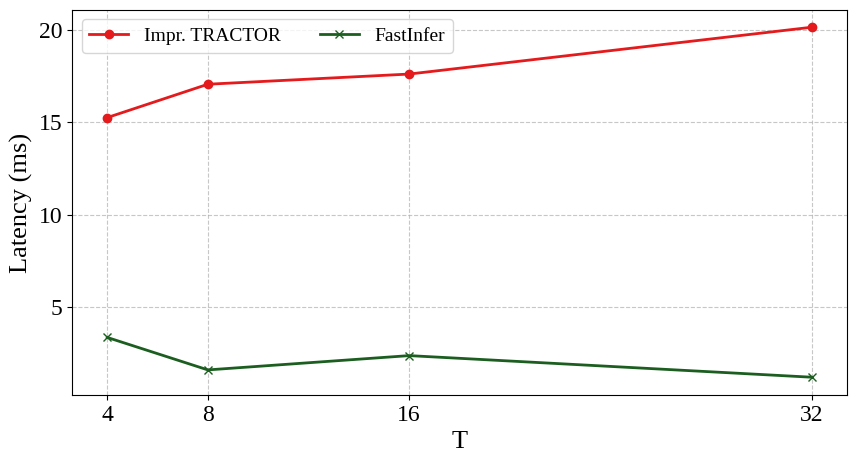

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ==========================================================
# Font settings
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif']
plt.rcParams['font.size'] = 17

# Font sizes for different elements
LABEL_SIZE = 19
TICK_SIZE = 17
LEGEND_SIZE = 14

# ==========================================================
# Configuration
# ==========================================================

log_file = "/content/avg_latency_micro"

# Colors
COLORS = {
    # XGBoost lines (emphasized, good)
    "Mahdi-XGBoost":   "#1B5E20",   # dark green

    # Tractor lines (bad → red)
    "UNICORN-Tractor": "#E41A1C",    # strong red
}

# Markers
MARKERS = {
    "Tractor": "o",
    "XGBoost": "x"
}

# ==========================================================
# Read log file
# ==========================================================

with open(log_file, "r") as f:
    lines = f.readlines()

# ==========================================================
# Parse data
# ==========================================================

data = defaultdict(lambda: {
    "T": [],
    "tractor": [],
    "xgboost": []
})

current_dataset = None

for line in lines:
    line = line.strip()

    if line and not line.startswith(("T =", "tractor", "xgboost")):
        current_dataset = line

    elif line.startswith("T ="):
        T_val = int(re.findall(r"\d+", line)[0])
        data[current_dataset]["T"].append(T_val)

    elif line.startswith("tractor"):
        data[current_dataset]["tractor"].append(float(line.split(":")[1]))

    elif line.startswith("xgboost"):
        data[current_dataset]["xgboost"].append(float(line.split(":")[1]))

# ==========================================================
# Plot: Line plot for all datasets
# ==========================================================

plt.figure(figsize=(10, 5))

T = data["Micro"]["T"]
plt.plot(T, data["Micro"]["tractor"],
         label="Impr. TRACTOR",
         color=COLORS["UNICORN-Tractor"],
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data["Micro"]["xgboost"],
         label="FastInfer",
         color=COLORS["Mahdi-XGBoost"],
         marker=MARKERS["XGBoost"],
         linewidth=2)

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

plt.xlabel("T", fontsize=LABEL_SIZE)
plt.ylabel("Latency (ms)", fontsize=LABEL_SIZE)
# plt.title("Latency Comparison")
plt.xticks(T, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.grid(True, linestyle="--", alpha=0.7)

plt.legend(ncol=2, loc="upper left", fontsize=LEGEND_SIZE)
plt.savefig("latency_micro.pdf", dpi=300, bbox_inches="tight")


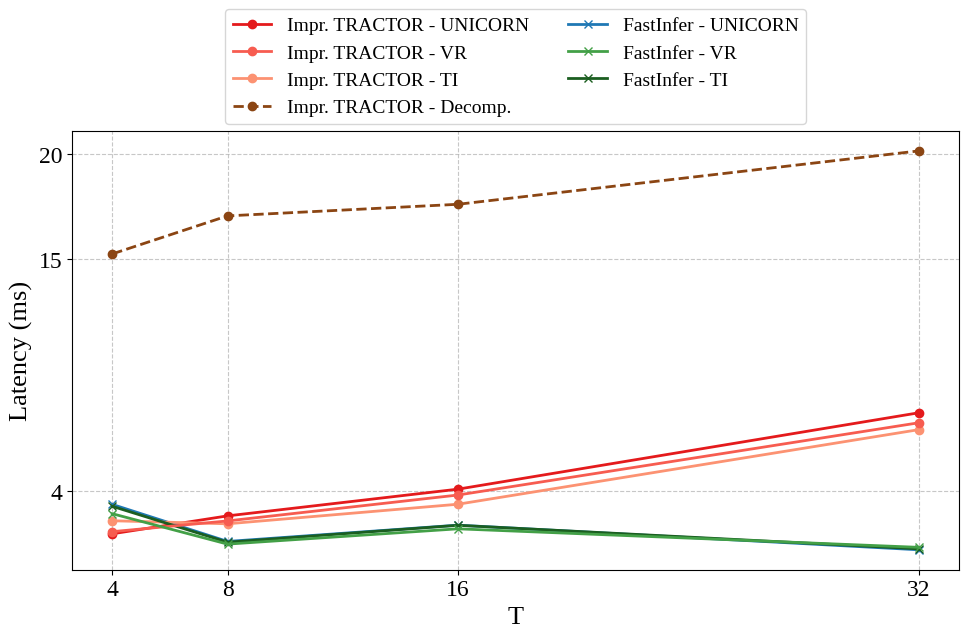

In [ ]:
import re
import matplotlib.pyplot as plt
import numpy as np
from collections import defaultdict

# ==========================================================
# Font settings
# ==========================================================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif']
plt.rcParams['font.size'] = 17

# Font sizes for different elements
LABEL_SIZE = 19
TICK_SIZE = 17
LEGEND_SIZE = 14

# ==========================================================
# Configuration
# ==========================================================

log_file_mono = "/content/avg_latency_mono"
log_file_micro = "/content/avg_latency_micro"

# Colors
COLORS = {
    # XGBoost lines (emphasized, good)
    "UNICORN-XGBoost": "#1F78B4",   # blue
    "Mahdi-XGBoost":   "#1B5E20",   # dark green

    # Tractor lines (bad → red)
    "UNICORN-Tractor": "#E41A1C",    # strong red
    "Mahdi-Tractor":   "#FC9272"     # lighter red for contrast
}

# Markers
MARKERS = {
    "Tractor": "o",
    "XGBoost": "x"
}

# ==========================================================
# Function to read and parse log file
# ==========================================================
def parse_log_file(log_file):
    with open(log_file, "r") as f:
        lines = f.readlines()

    data = defaultdict(lambda: {
        "T": [],
        "tractor": [],
        "xgboost": []
    })

    current_dataset = None

    for line in lines:
        line = line.strip()

        if line and not line.startswith(("T =", "tractor", "xgboost")):
            current_dataset = line

        elif line.startswith("T ="):
            T_val = int(re.findall(r"\d+", line)[0])
            data[current_dataset]["T"].append(T_val)

        elif line.startswith("tractor"):
            data[current_dataset]["tractor"].append(float(line.split(":")[1]))

        elif line.startswith("xgboost"):
            data[current_dataset]["xgboost"].append(float(line.split(":")[1]))

    return data

# ==========================================================
# Parse both files
# ==========================================================
data_mono = parse_log_file(log_file_mono)
data_micro = parse_log_file(log_file_micro)

# ==========================================================
# Plot: Combined line plot
# ==========================================================

plt.figure(figsize=(10, 7))

# MONO DATA (from first file)
# URLLC-UNICORN
T = data_mono["URLLC-UNICORN"]["T"]
plt.plot(T, data_mono["URLLC-UNICORN"]["tractor"],
         label="Impr. TRACTOR - UNICORN",
         color=COLORS["UNICORN-Tractor"],
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data_mono["URLLC-UNICORN"]["xgboost"],
         label="FastInfer - UNICORN",
         color=COLORS["UNICORN-XGBoost"],
         marker=MARKERS["XGBoost"],
         linewidth=2)

# URLLC-Mahdi
T = data_mono["URLLC-Mahdi"]["T"]
plt.plot(T, data_mono["URLLC-Mahdi"]["tractor"],
         label="Impr. TRACTOR - TI",
         color=COLORS["Mahdi-Tractor"],
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data_mono["URLLC-Mahdi"]["xgboost"],
         label="FastInfer - TI",
         color=COLORS["Mahdi-XGBoost"],
         marker=MARKERS["XGBoost"],
         linewidth=2)

# eMBB-Mahdi
T = data_mono["eMBB-Mahdi"]["T"]
plt.plot(T, data_mono["eMBB-Mahdi"]["tractor"],
         label="Impr. TRACTOR - VR",
         color="#F75C50",
         marker=MARKERS["Tractor"],
         linewidth=2)

plt.plot(T, data_mono["eMBB-Mahdi"]["xgboost"],
         label="FastInfer - VR",
         color="#43A047",
         marker=MARKERS["XGBoost"],
         linewidth=2)

# MICRO DATA (from second file)
T = data_micro["Micro"]["T"]
plt.plot(T, data_micro["Micro"]["tractor"],
         label="Impr. TRACTOR - Decomp.",
         color="#8B4513",  # Brown color to distinguish
         marker=MARKERS["Tractor"],
         linewidth=2,
         linestyle='--')  # Dashed line to distinguish

# plt.plot(T, data_micro["Micro"]["xgboost"],
#          label="FastInfer - Micro",
#          color="#9C27B0",  # Purple color to distinguish
#          marker=MARKERS["XGBoost"],
#          linewidth=2,
#          linestyle='--')  # Dashed line to distinguish

# ----------------------------------------------------------
# Formatting
# ----------------------------------------------------------

plt.xlabel("T", fontsize=LABEL_SIZE)
plt.ylabel("Latency (ms)", fontsize=LABEL_SIZE)
plt.xticks(T, fontsize=TICK_SIZE)
plt.yticks([4, 15, 20], fontsize=TICK_SIZE)
plt.grid(True, linestyle="--", alpha=0.7)
# plt.ylim()

# Combined legend with custom order
handles, labels = plt.gca().get_legend_handles_labels()
desired_order = [
    "Impr. TRACTOR - UNICORN",
    "Impr. TRACTOR - VR",
    "Impr. TRACTOR - TI",
    "Impr. TRACTOR - Decomp.",
    "FastInfer - UNICORN",
    "FastInfer - VR",
    "FastInfer - TI",
    # "FastInfer - Micro"
]
ordered_handles = [handles[labels.index(lbl)] for lbl in desired_order]
plt.legend(
    ordered_handles,
    desired_order,
    ncol=2,
    loc="upper center",
    fontsize=LEGEND_SIZE,
    bbox_to_anchor=(0.5, 1.3)
)

plt.tight_layout()
plt.savefig("latency_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

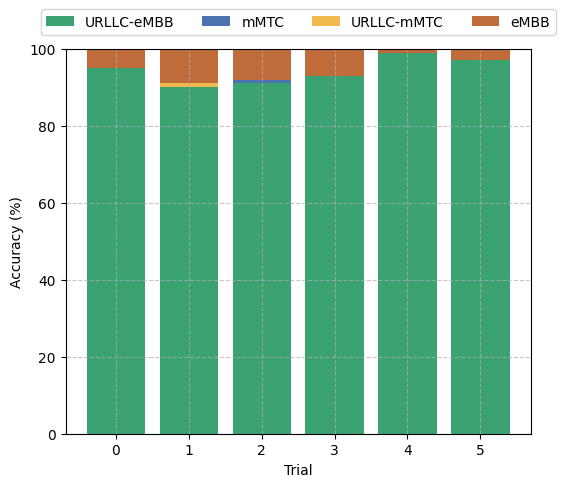

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Dynamic input
# =========================
# Trials (can be any length)
trials = list(range(0, 6))   # e.g., 1..N
num_trials = len(trials)

# Accuracy composition per label (each column MUST sum to 100)
acc_label_4 = np.array([95, 90, 91, 93, 99,  97]) # URLLC-eMBB
acc_label_1 = np.array([ 0,  0,  1,  0,  0,   0]) # mMTC
acc_label_3 = np.array([ 0,  1,  0,  0,  0,   0]) # URLLC-mMTC
acc_label_0 = np.array([ 5,  9,  8,  7,  1,   3]) # eMBB

x = np.arange(num_trials)

# =========================
# Colors (cool & attractive)
# =========================
colors = {
    "Label 0": "#C06C3A",
    "Label 1": "#4C72B0",  # strong blue
    "Label 3": "#F2B94F",  # golden yellow
    "Label 4": "#3BA272",  # green
}

# =========================
# Figure size scales with trials
# =========================
# plt.figure(figsize=(0.6 * num_trials, 5))
plt.figure(figsize=(num_trials, 5))

bottom = np.zeros(num_trials)

# =========================
# Vertical stacked bars
# =========================
plt.bar(x, acc_label_4, bottom=bottom, color=colors["Label 4"], label="URLLC-eMBB")
bottom += acc_label_4

plt.bar(x, acc_label_1, bottom=bottom, color=colors["Label 1"], label="mMTC")
bottom += acc_label_1

plt.bar(x, acc_label_3, bottom=bottom, color=colors["Label 3"], label="URLLC-mMTC")
bottom += acc_label_3

plt.bar(x, acc_label_0, bottom=bottom, color=colors["Label 0"], label="eMBB")

# =========================
# Axes & layout
# =========================
plt.xlabel("Trial")
plt.ylabel("Accuracy (%)")
plt.xticks(x, trials)
plt.ylim(0, 100)
# plt.title("Accuracy Composition per Trial")

plt.legend(
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12)
)
plt.grid(True, linestyle="--", alpha=0.7)

plt.savefig("smartgw_unicorn.pdf", dpi=300, bbox_inches="tight")
plt.show()


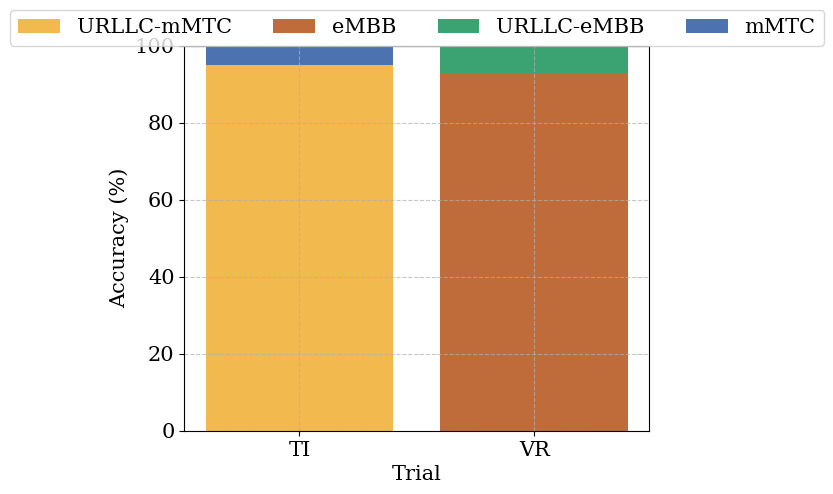

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Dynamic input
# =========================
# Trials as text labels
trials = ["TI", "VR"]
num_trials = len(trials)

# Accuracy composition per label (each column MUST sum to 100)
acc_label_4 = np.array([ 0,  7])   # URLLC-eMBB
acc_label_1 = np.array([ 5,  0])   # mMTC
acc_label_3 = np.array([95,  0])   # URLLC-mMTC
acc_label_0 = np.array([ 0, 93])   # eMBB

x = np.arange(num_trials)

# =========================
# Colors (cool & attractive)
# =========================
colors = {
    "Label 0": "#C06C3A",  # eMBB (warm, slightly bright)
    "Label 1": "#4C72B0",  # mMTC (blue)
    "Label 3": "#F2B94F",  # URLLC-mMTC (golden yellow)
    "Label 4": "#3BA272",  # URLLC-eMBB (green)
}

# =========================
# Figure
# =========================
plt.figure(figsize=(6, 5))

bottom = np.zeros(num_trials)

# =========================
# Vertical stacked bars
# Stack order: bottom → top
# =========================
plt.bar(x, acc_label_3, bottom=bottom, color=colors["Label 3"], label="URLLC-mMTC")
bottom += acc_label_3

plt.bar(x, acc_label_0, bottom=bottom, color=colors["Label 0"], label="eMBB")
bottom += acc_label_0

plt.bar(x, acc_label_4, bottom=bottom, color=colors["Label 4"], label="URLLC-eMBB")
bottom += acc_label_4

plt.bar(x, acc_label_1, bottom=bottom, color=colors["Label 1"], label="mMTC")

# =========================
# Axes & layout
# =========================
plt.xlabel("Trial")
plt.ylabel("Accuracy (%)")
plt.xticks(x, trials)
plt.ylim(0, 100)

plt.legend(
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.12)
)

plt.grid(True, linestyle="--", alpha=0.7)

plt.savefig("smartgw_mahdi_acc.pdf", dpi=300, bbox_inches="tight")
plt.show()


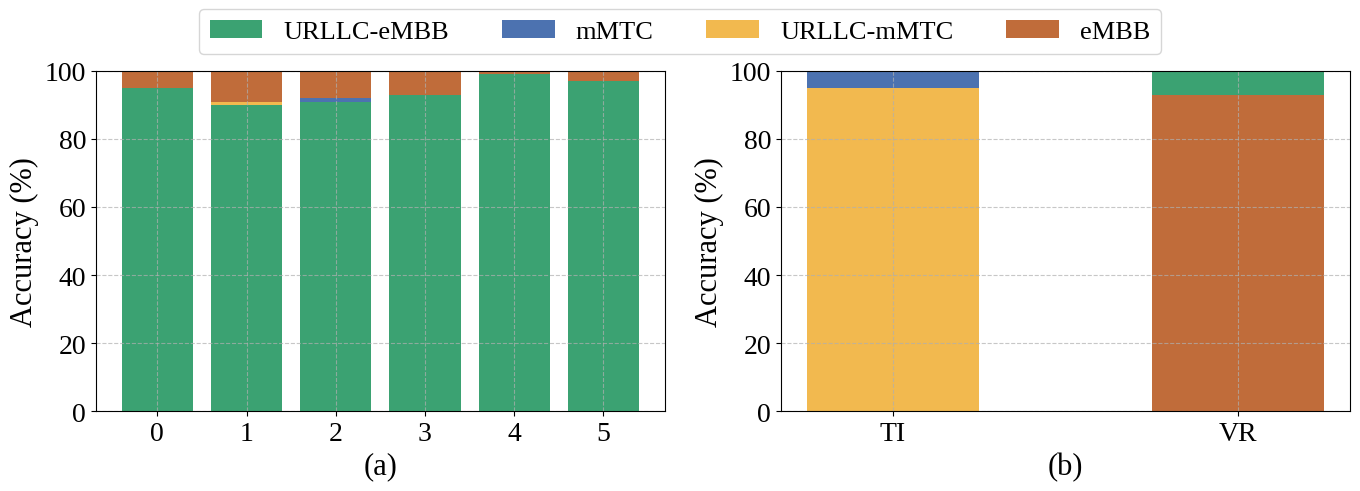

In [2]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Font settings
# =========================
# Try Times New Roman, fall back to serif if not available
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif']
plt.rcParams['font.size'] = 20

# Font sizes for different elements
LABEL_SIZE = 22
TICK_SIZE = 20
LEGEND_SIZE = 19

# =========================
# Create figure with 2 subplots
# =========================
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# =========================
# Colors (shared between subplots)
# =========================
colors = {
    "Label 0": "#C06C3A",  # eMBB
    "Label 1": "#4C72B0",  # mMTC
    "Label 3": "#F2B94F",  # URLLC-mMTC
    "Label 4": "#3BA272",  # URLLC-eMBB
}

# =========================
# SUBPLOT 1 (Left)
# =========================
trials_1 = list(range(0, 6))
num_trials_1 = len(trials_1)

acc_label_4_1 = np.array([95, 90, 91, 93, 99, 97])  # URLLC-eMBB
acc_label_1_1 = np.array([0, 0, 1, 0, 0, 0])        # mMTC
acc_label_3_1 = np.array([0, 1, 0, 0, 0, 0])        # URLLC-mMTC
acc_label_0_1 = np.array([5, 9, 8, 7, 1, 3])        # eMBB

x1 = np.arange(num_trials_1)
bottom_1 = np.zeros(num_trials_1)

ax1.bar(x1, acc_label_4_1, bottom=bottom_1, color=colors["Label 4"], label="URLLC-eMBB")
bottom_1 += acc_label_4_1

ax1.bar(x1, acc_label_1_1, bottom=bottom_1, color=colors["Label 1"], label="mMTC")
bottom_1 += acc_label_1_1

ax1.bar(x1, acc_label_3_1, bottom=bottom_1, color=colors["Label 3"], label="URLLC-mMTC")
bottom_1 += acc_label_3_1

ax1.bar(x1, acc_label_0_1, bottom=bottom_1, color=colors["Label 0"], label="eMBB")

ax1.set_xlabel("(a)", fontsize=LABEL_SIZE)
ax1.set_ylabel("Accuracy (%)", fontsize=LABEL_SIZE)
ax1.set_xticks(x1)
ax1.set_xticklabels(trials_1, fontsize=TICK_SIZE)
ax1.tick_params(axis='y', labelsize=TICK_SIZE)
ax1.set_ylim(0, 100)
ax1.grid(True, linestyle="--", alpha=0.7)

# =========================
# SUBPLOT 2 (Right) - with smaller bar width and closer spacing
# =========================
trials_2 = ["TI", "VR"]
num_trials_2 = len(trials_2)

acc_label_4_2 = np.array([0, 7])    # URLLC-eMBB
acc_label_1_2 = np.array([5, 0])    # mMTC
acc_label_3_2 = np.array([95, 0])   # URLLC-mMTC
acc_label_0_2 = np.array([0, 93])   # eMBB

# Adjust positions to bring bars closer together
bar_width = 0.1
x2 = np.array([0.2, 0.4])  # Custom positions instead of [0, 1]

bottom_2 = np.zeros(num_trials_2)

ax2.bar(x2, acc_label_3_2, bottom=bottom_2, width=bar_width, color=colors["Label 3"], label="URLLC-mMTC")
bottom_2 += acc_label_3_2

ax2.bar(x2, acc_label_0_2, bottom=bottom_2, width=bar_width, color=colors["Label 0"], label="eMBB")
bottom_2 += acc_label_0_2

ax2.bar(x2, acc_label_4_2, bottom=bottom_2, width=bar_width, color=colors["Label 4"], label="URLLC-eMBB")
bottom_2 += acc_label_4_2

ax2.bar(x2, acc_label_1_2, bottom=bottom_2, width=bar_width, color=colors["Label 1"], label="mMTC")

ax2.set_xlabel("(b)", fontsize=LABEL_SIZE)
ax2.set_ylabel("Accuracy (%)", fontsize=LABEL_SIZE)
ax2.set_xticks(x2)
ax2.set_xticklabels(trials_2, fontsize=TICK_SIZE)
ax2.tick_params(axis='y', labelsize=TICK_SIZE)
ax2.set_ylim(0, 100)
ax2.grid(True, linestyle="--", alpha=0.7)

# =========================
# Shared legend at the top
# =========================
handles, labels = ax1.get_legend_handles_labels()
fig.legend(
    handles, labels,
    ncol=4,
    loc="upper center",
    bbox_to_anchor=(0.5, 1.03),
    fontsize=LEGEND_SIZE
)

plt.tight_layout()
plt.subplots_adjust(top=0.88)  # Make room for legend

plt.savefig("smartgw_combined.pdf", dpi=300, bbox_inches="tight")
plt.show()

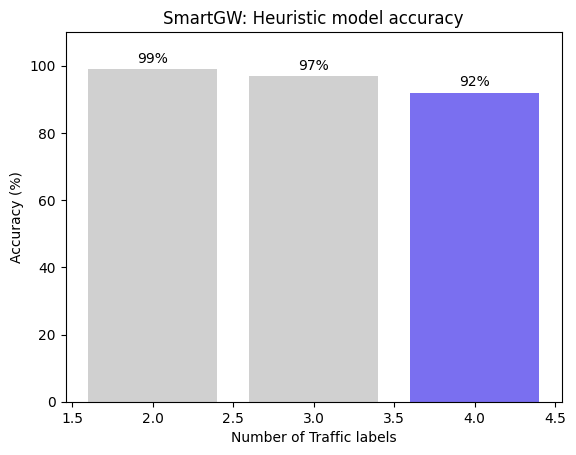

In [ ]:
import matplotlib.pyplot as plt

# Data
labels = [2, 3, 4]
accuracy = [99, 97, 92]

# Colors: neutral gray + highlighted blue
# colors = ["#C7C7C7", "#C7C7C7", "#2CB1A6"]
colors = ["#D0D0D0", "#D0D0D0", "#7A6FF0"]
# colors = ["#CFCFCF", "#CFCFCF", "#3BA272"]
# colors = ["#E0E0E0", "#E0E0E0", "#2F2F2F"]


plt.figure()
bars = plt.bar(labels, accuracy, color=colors)

plt.xlabel("Number of Traffic labels")
plt.ylabel("Accuracy (%)")
plt.title("SmartGW: Heuristic model accuracy")
plt.ylim(0, 110)

# Annotate bars
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 1,
        f"{height}%",
        ha="center",
        va="bottom"
    )

plt.show()


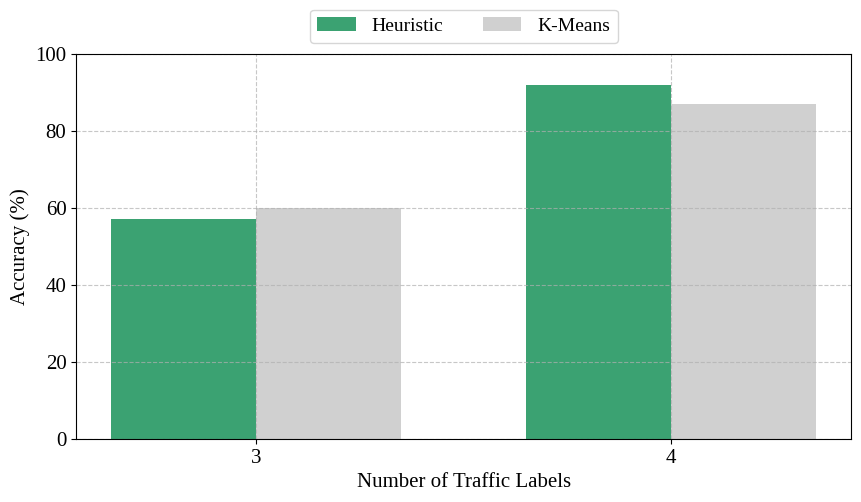

In [3]:
import matplotlib.pyplot as plt
import numpy as np

# =========================
# Font settings
# =========================
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Liberation Serif']
plt.rcParams['font.size'] = 15

# Font sizes for different elements
LABEL_SIZE = 15
TICK_SIZE = 15
LEGEND_SIZE = 14

# Data
labels = [3, 4]
heuristic_acc = [57, 92]
kmeans_acc = [60, 87]

# labels = [2, 4]
# heuristic_acc = [99, 92]
# kmeans_acc = [96, 87]

x = np.arange(len(labels))  # positions
width = 0.35                # bar width

# Colors (cool + attractive)
heuristic_color = "#3BA272"
kmeans_color = "#D0D0D0"

plt.figure(figsize=(10, 5))

bars1 = plt.bar(x - width/2, heuristic_acc, width,
                label="Heuristic", color=heuristic_color)

bars2 = plt.bar(x + width/2, kmeans_acc, width,
                label="K-Means", color=kmeans_color)

# Axes & labels
plt.xlabel("Number of Traffic Labels", fontsize=LABEL_SIZE)
plt.ylabel("Accuracy (%)", fontsize=LABEL_SIZE)
# plt.title("SmartGW: Model Accuracy Comparison")
plt.xticks(x, labels, fontsize=TICK_SIZE)
plt.yticks(fontsize=TICK_SIZE)
plt.ylim(0, 100)

# Annotate bars
# for bars in [bars1, bars2]:
#     for bar in bars:
#         height = bar.get_height()
#         plt.text(
#             bar.get_x() + bar.get_width() / 2,
#             height + 1,
#             f"{height}%",
#             ha="center",
#             va="bottom",
#             fontsize=9
#         )

plt.grid(True, linestyle="--", alpha=0.7)
plt.legend(ncol=3, loc="upper center",
           bbox_to_anchor=(0.5, 1.14),
           fontsize=LEGEND_SIZE
           )
plt.savefig("smartgw_acc.pdf", dpi=300, bbox_inches="tight")
plt.show()

In [ ]:
import re

# --- Sample log text ---
sample_log = """
   6725 KPM ind_msg latency = 1745688163047219 [μs]
UE ID type = gNB-CU-UP, gnb_cu_cp_ue_e1ap = 1
ran_ue_id = 1
DRB.PdcpSduVolumeDL = 0 [kb]
DRB.PdcpSduVolumeUL = 0 [kb]

   6726 KPM ind_msg latency = 1747887186303287 [μs]
UE ID type = gNB-DU, gnb_cu_ue_f1ap = 1
ran_ue_id = 1
DRB.RlcSduDelayDl = 0.00 [μs]
DRB.UEThpDl = 0.00 [kbps]
DRB.UEThpUl = 0.00 [kbps]
RRU.PrbTotDl = 30 [PRBs]
RRU.PrbTotUl = 325 [PRBs]
"""

# --- Regex patterns (Python-compatible) ---
patterns = {
    "UE ID type": r"UE ID type = ([\w-]+)",
    "gnb_cu_cp_ue_e1ap": r"gnb_cu_cp_ue_e1ap = (\d+)",
    "gnb_cu_ue_f1ap": r"gnb_cu_ue_f1ap = (\d+)",
    "ran_ue_id": r"ran_ue_id = (\d+)",
    "DRB.PdcpSduVolumeDL": r"DRB\.PdcpSduVolumeDL = ([\d.]+) \[kb\]",
    "DRB.PdcpSduVolumeUL": r"DRB\.PdcpSduVolumeUL = ([\d.]+) \[kb\]",
    "DRB.RlcSduDelayDl": r"DRB\.RlcSduDelayDl = ([\d.]+) \[μs\]",
    "DRB.UEThpDl": r"DRB\.UEThpDl = ([\d.]+) \[kbps\]",
    "DRB.UEThpUl": r"DRB\.UEThpUl = ([\d.]+) \[kbps\]",
    "RRU.PrbTotDl": r"RRU\.PrbTotDl = ([\d.]+) \[PRBs\]",
    "RRU.PrbTotUl": r"RRU\.PrbTotUl = ([\d.]+) \[PRBs\]",
}

print("=== Testing Regex Matches ===")
lines = [l.strip() for l in sample_log.splitlines() if l.strip()]
for line in lines:
    print(f"\nLINE: {line}")
    matched_any = False
    for name, pattern in patterns.items():
        match = re.search(pattern, line)
        if match:
            print(f"  ✅ Matched {name}: {match.group(1)}")
            matched_any = True
    if not matched_any:
        print("  ❌ No pattern matched")


=== Testing Regex Matches ===

LINE: 6725 KPM ind_msg latency = 1745688163047219 [μs]
  ❌ No pattern matched

LINE: UE ID type = gNB-CU-UP, gnb_cu_cp_ue_e1ap = 1
  ✅ Matched UE ID type: gNB-CU-UP
  ✅ Matched gnb_cu_cp_ue_e1ap: 1

LINE: ran_ue_id = 1
  ✅ Matched ran_ue_id: 1

LINE: DRB.PdcpSduVolumeDL = 0 [kb]
  ✅ Matched DRB.PdcpSduVolumeDL: 0

LINE: DRB.PdcpSduVolumeUL = 0 [kb]
  ✅ Matched DRB.PdcpSduVolumeUL: 0

LINE: 6726 KPM ind_msg latency = 1747887186303287 [μs]
  ❌ No pattern matched

LINE: UE ID type = gNB-DU, gnb_cu_ue_f1ap = 1
  ✅ Matched UE ID type: gNB-DU
  ✅ Matched gnb_cu_ue_f1ap: 1

LINE: ran_ue_id = 1
  ✅ Matched ran_ue_id: 1

LINE: DRB.RlcSduDelayDl = 0.00 [μs]
  ✅ Matched DRB.RlcSduDelayDl: 0.00

LINE: DRB.UEThpDl = 0.00 [kbps]
  ✅ Matched DRB.UEThpDl: 0.00

LINE: DRB.UEThpUl = 0.00 [kbps]
  ✅ Matched DRB.UEThpUl: 0.00

LINE: RRU.PrbTotDl = 30 [PRBs]
  ✅ Matched RRU.PrbTotDl: 30

LINE: RRU.PrbTotUl = 325 [PRBs]
  ✅ Matched RRU.PrbTotUl: 325


In [ ]:
import pandas as pd
import numpy as np

# Read CSV file
df = pd.read_csv("/content/embb_1010123456010_metrics.csv")  # 👈 replace with your actual file name or path

# Compute mean for each column, keeping NaN columns unchanged
averages = df.apply(lambda col: col.mean() if col.notna().any() else np.nan)

avg_dict = averages.to_dict()

print(avg_dict)

# {'Timestamp': 1667165417533.8477, 'num_ues': 1.0, 'IMSI': 1010123456002.0, 'RNTI': 75.09719588863386, 'Unnamed: 4': nan, 'slicing_enabled': 1.0, 'slice_id': 1.0, 'slice_prb': 18.0, 'power_multiplier': 1.0, 'scheduling_policy': 1.0, 'Unnamed: 10': nan, 'dl_mcs': 1.72031630615707, 'dl_n_samples': 55.49456142101587, 'dl_buffer [bytes]': 4792.096397565113, 'tx_brate downlink [Mbps]': 0.20226417124039517, 'tx_pkts downlink': 15.853807005288893, 'tx_errors downlink (%)': 0.0, 'dl_cqi': 6.709994766989323, 'Unnamed: 18': nan, 'ul_mcs': 2.6767620197585074, 'ul_n_samples': 11.697335595249974, 'ul_buffer [bytes]': 771.5226025346772, 'rx_brate uplink [Mbps]': 0.1392692611515817, 'rx_pkts uplink': 3.337191897016266, 'rx_errors uplink (%)': 0.0, 'ul_rssi': 0.0, 'ul_sinr': 6.47131010877158, 'phr': 5.948807504241094, 'Unnamed: 28': nan, 'sum_requested_prbs': 663.8665801816186, 'sum_granted_prbs': 267.45055383694245, 'Unnamed: 31': nan, 'dl_pmi': 0.0, 'dl_ri': 0.0, 'ul_n': 0.0, 'ul_turbo_iters': 0.18870372218341483}

{'Timestamp': 1617070582085.1682, 'num_ues': 5.984090909090909, 'IMSI': 1010123456010.0, 'RNTI': 71.0, 'Unnamed: 4': nan, 'slicing_enabled': 1.0, 'slice_id': 0.0, 'slice_prb': 6.0, 'power_multiplier': 1.0, 'scheduling_policy': 0.0, 'Unnamed: 10': nan, 'dl_mcs': 0.06061734090909091, 'dl_n_samples': 0.35, 'dl_buffer [bytes]': 100162.9340909091, 'tx_brate downlink [Mbps]': 0.0004298222954545454, 'tx_pkts downlink': 0.10454545454545454, 'tx_errors downlink (%)': 0.0, 'dl_cqi': 6.867131977272727, 'Unnamed: 18': nan, 'ul_mcs': 0.18639893181818182, 'ul_n_samples': 0.4340909090909091, 'ul_buffer [bytes]': 0.0, 'rx_brate uplink [Mbps]': 0.0021793454545454547, 'rx_pkts uplink': 0.12727272727272726, 'rx_errors uplink (%)': 0.25548590909090907, 'ul_rssi': 0.0, 'ul_sinr': 0.34768215909090905, 'phr': 0.49318181818181817, 'Unnamed: 28': nan, 'sum_requested_prbs': 0.075, 'sum_granted_prbs': 273.7022727272727, 'Unnamed: 31': nan, 'dl_pmi': 0.0, 'dl_ri': 0.0, 'ul_n': 0.0, 'ul_turbo_iters': 0.03655502272

In [ ]:
print(averages)

Timestamp                   1.617071e+12
num_ues                     5.984091e+00
IMSI                        1.010123e+12
RNTI                        7.100000e+01
Unnamed: 4                           NaN
slicing_enabled             1.000000e+00
slice_id                    0.000000e+00
slice_prb                   6.000000e+00
power_multiplier            1.000000e+00
scheduling_policy           0.000000e+00
Unnamed: 10                          NaN
dl_mcs                      6.061734e-02
dl_n_samples                3.500000e-01
dl_buffer [bytes]           1.001629e+05
tx_brate downlink [Mbps]    4.298223e-04
tx_pkts downlink            1.045455e-01
tx_errors downlink (%)      0.000000e+00
dl_cqi                      6.867132e+00
Unnamed: 18                          NaN
ul_mcs                      1.863989e-01
ul_n_samples                4.340909e-01
ul_buffer [bytes]           0.000000e+00
rx_brate uplink [Mbps]      2.179345e-03
rx_pkts uplink              1.272727e-01
rx_errors uplink

In [ ]:
a = [1,2,3,4,5]
a[1:-1]

[2, 3, 4]

In [ ]:
import numpy as np

data_sck = """1761659946683,3,1010123456002.0,3.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483"""
last_timestamp = 0
data_sck = data_sck.replace(',,', ',')
if data_sck[0] == 'm':
    data_sck = data_sck[1:]

kpi_new = np.fromstring(data_sck, sep=',')
if kpi_new.shape[0] < 31:
    print('Discarding KPI: too short')
    print(f"Received data length: {kpi_new.shape[0]}, data: {data_sck}")


ts = kpi_new[0]
if ts <= last_timestamp:
    print("continue")
last_timestamp = ts

In [ ]:
print(kpi_new)

[1.76165995e+12 3.00000000e+00 1.01012346e+12 3.00000000e+00
 1.00000000e+00 1.00000000e+00 1.80000000e+01 1.00000000e+00
 1.00000000e+00 1.72031631e+00 5.54945614e+01 4.79209640e+03
 2.02264171e-01 1.58538070e+01 0.00000000e+00 6.70999477e+00
 2.67676202e+00 1.16973356e+01 7.71522603e+02 1.39269261e-01
 3.33719190e+00 0.00000000e+00 0.00000000e+00 6.47131011e+00
 5.94880750e+00 6.63866580e+02 2.67450554e+02 0.00000000e+00
 0.00000000e+00 0.00000000e+00 1.88703722e-01]


In [ ]:
kpi_new.shape[0]

31

In [ ]:


data = """22025-11-03T12:59:48.846499,1762174788846,11,1010123456002.0,1.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.846742,1762174788846,11,1010123456002.0,2.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.846954,1762174788846,11,1010123456002.0,3.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847339,1762174788847,11,1010123456002.0,4.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847607,1762174788847,11,1010123456002.0,5.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847797,1762174788847,11,1010123456002.0,6.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847997,1762174788847,11,1010123456002.0,7.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.848198,1762174788848,11,1010123456002.0,8.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.848468,1762174788848,11,1010123456002.0,9.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.848749,1762174788848,11,1010123456002.0,10.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.844018,1762174788844,11,1010123456002.0,11.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483"""

rows = [r.strip() for r in data.split("\n") if r.strip()]

for r in rows:
  # Drop readable timestamp (first field)
  parts = r.split(",")
  if len(parts) < 2:
      continue
  print(parts)
  print(len(parts))
  # remove first column (readable timestamp)
  numeric_line = ",".join(parts[1:])


['22025-11-03T12:59:48.846499', '1762174788846', '11', '1010123456002.0', '1.0', '1.0', '1.0', '18.0', '1.0', '1.0', '1.72031630615707', '55.49456142101587', '4792.096397565113', '0.20226417124039517', '15.853807005288893', '0.0', '6.709994766989323', '2.6767620197585074', '11.697335595249974', '771.5226025346772', '0.1392692611515817', '3.337191897016266', '0.0', '0.0', '6.47131010877158', '5.948807504241094', '663.8665801816186', '267.45055383694245', '0.0', '0.0', '0.0', '0.18870372218341483']
32
['2025-11-03T12:59:48.846742', '1762174788846', '11', '1010123456002.0', '2.0', '1.0', '1.0', '18.0', '1.0', '1.0', '1.72031630615707', '55.49456142101587', '4792.096397565113', '0.20226417124039517', '15.853807005288893', '0.0', '6.709994766989323', '2.6767620197585074', '11.697335595249974', '771.5226025346772', '0.1392692611515817', '3.337191897016266', '0.0', '0.0', '6.47131010877158', '5.948807504241094', '663.8665801816186', '267.45055383694245', '0.0', '0.0', '0.0', '0.18870372218341

In [ ]:
numeric_line

'1761659946683,3,1010123456002.0,3.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483'

In [ ]:
import time
from time import sleep

t0 = time.time()
sleep(1)
t1 = time.time()
predict_time_ms = (t1 - t0) * 1000.0
print(predict_time_ms)

1000.42724609375


In [ ]:
num_ues = 200
base_ueid = 100  # starting from 001010000000100

template = (
    "INSERT INTO `AuthenticationSubscription` "
    "(`ueid`, `authenticationMethod`, `encPermanentKey`, `protectionParameterId`, `sequenceNumber`, "
    "`authenticationManagementField`, `algorithmId`, `encOpcKey`, `encTopcKey`, "
    "`vectorGenerationInHss`, `n5gcAuthMethod`, `rgAuthenticationInd`, `supi`) VALUES\n"
    "('{ueid}', '5G_AKA', 'fec86ba6eb707ed08905757b1bb44b8f', "
    "'fec86ba6eb707ed08905757b1bb44b8f', "
    "'{{\"sqn\": \"000000000020\", \"sqnScheme\": \"NON_TIME_BASED\", \"lastIndexes\": {{\"ausf\": 0}}}}', "
    "'8000', 'milenage', 'C42449363BBAD02B66D16BC975D77CC1', NULL, NULL, NULL, NULL, '{ueid}');"
)

for i in range(base_ueid, base_ueid + num_ues):
    ueid = f"001010000000{i:03d}"
    print(template.format(ueid=ueid))


In [ ]:
num_ues = 200
base_ueid = 100

template = (
    "INSERT INTO `SessionManagementSubscriptionData` "
    "(`ueid`, `servingPlmnid`, `singleNssai`, `dnnConfigurations`) VALUES \n"
    "('{ueid}', '00101', '{{\"sst\": 1, \"sd\": \"FFFFFF\"}}', "
    "'{{\"oai\":{{\"pduSessionTypes\":{{ \"defaultSessionType\": \"IPV4\"}},"
    "\"sscModes\": {{\"defaultSscMode\": \"SSC_MODE_1\"}},"
    "\"5gQosProfile\": {{\"5qi\": 6, \"arp\":{{\"priorityLevel\": 1, \"preemptCap\": \"NOT_PREEMPT\", "
    "\"preemptVuln\":\"NOT_PREEMPTABLE\"}}, \"priorityLevel\":1}},"
    "\"sessionAmbr\":{{\"uplink\":\"1000Mbps\", \"downlink\":\"1000Mbps\"}}}}}}');"
)

for i in range(base_ueid, base_ueid + num_ues):
    ueid = f"001010000000{i:03d}"
    print(template.format(ueid=ueid))


In [ ]:
def is_number(s):
    """Return True if s is numeric (int or float)."""
    try:
        float(s)
        return True
    except (ValueError, TypeError):
        return False
s = ""
is_number(s)

False

In [ ]:
import queue, time
from datetime import datetime
import numpy as np
# data_queue = queue.Queue()

def socket_listener(control_sck):
    """Receive data from TCP and enqueue each UE row."""
    data = control_sck

    rows = [r.strip() for r in data.split("\n") if r.strip()]
    # recv_time = time.time()

    # # Assign a batch ID to all rows from this KPM message
    # batch_id = datetime.utcnow().strftime("%Y%m%d%H%M%S%f")
    batch_size = len(rows)

    for r in rows:
        parts = r.split(",")
        if len(parts) < 2:
            continue

        numeric_line = ",".join(parts[1:])  # remove readable timestamp
        # data_queue.put((batch_id, numeric_line, recv_time, batch_size))
    return numeric_line, batch_size

In [ ]:

control_sck = """2025-11-03T12:59:48.846499,1762174788846,11,1010123456002.0,1.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.846742,1762174788846,11,1010123456002.0,2.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.846954,1762174788846,11,1010123456002.0,3.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847339,1762174788847,11,1010123456002.0,4.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847607,1762174788847,11,1010123456002.0,5.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847797,1762174788847,11,1010123456002.0,6.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.847997,1762174788847,11,1010123456002.0,7.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.848198,1762174788848,11,1010123456002.0,8.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.848468,1762174788848,11,1010123456002.0,9.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.848749,1762174788848,11,1010123456002.0,10.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483
2025-11-03T12:59:48.844018,1762174788844,11,1010123456002.0,11.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483

1"""
socket_listener(control_sck=control_sck)

('1762174788844,11,1010123456002.0,11.0,1.0,1.0,18.0,1.0,1.0,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0.0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0.0,0.0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0.0,0.0,0.0,0.18870372218341483',
 12)

In [ ]:
control_sck = """2025-10-30T14:28:22.844880,20251030142734316782,1,1,1,0,0,0.00,0.00,0.00,5,50
2025-10-30T14:28:22.845260,20251030142734316782,2,2,2,0,0,0.00,0.00,0.00,5,50
2025-10-30T14:28:22.845504,20251030142734316782,3,3,3,0,0,0.00,0.00,0.00,5,50
2025-10-30T14:28:22.845794,20251030142734316782,4,4,4,0,0,0.00,0.00,0.00,5,50
2025-10-30T14:28:23.843582,20251030142734316782,5,5,5,0,0,0.00,0.00,0.00,5,50"""

10


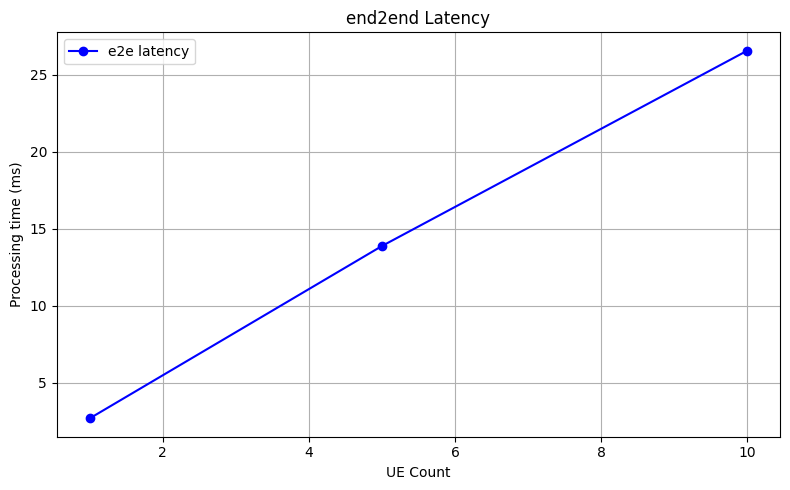

In [ ]:
import re
import matplotlib.pyplot as plt

# List of log files and corresponding UE counts
log_files = ["/content/tractor-mono-1-ue.txt", "/content/tractor-mono-5-ues.txt", "/content/tractor-mono-10-ues.txt"]
ue_counts = [1, 5, 10]

wall_clock_values = []

# Regex to match wall_clock in the "Completed" line
wall_clock_regex = re.compile(r'wall_clock=([0-9.]+) ms')

for log_file in log_files:
    with open(log_file, "r") as f:
        wall_clock_list = []
        for line in f:
            if "Completed" in line:
                match = wall_clock_regex.search(line)
                if match:
                    wall_clock_list.append(float(match.group(1)))

        # Take average wall_clock if multiple entries per file
        if wall_clock_list:
            avg_wall_clock = sum(wall_clock_list) / len(wall_clock_list)
            wall_clock_values.append(avg_wall_clock)
        else:
            wall_clock_values.append(None)

# Plot
plt.figure(figsize=(8,5))
plt.plot(ue_counts, wall_clock_values, marker='o', linestyle='-', color='blue', label='e2e latency')
plt.xlabel("UE Count")
plt.ylabel("Processing time (ms)")
plt.title("end2end Latency")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
wall_clock_values

[2.70130081300813, 13.883489304812835, 26.55550847457627]

In [ ]:
data = "2025-11-06T09:25:50.776399,1762421150776,1,1.0,4792.096397565113,6.709994766989323,1.72031630615707,55.49456142101587,0,0,1,5.948807504241094,1,0.1392692611515817,0,3.337191897016266,1,1,18,1,267.45055383694245,663.8665801816186,0.20226417124039517,0,15.853807005288893,771.5226025346772,2.6767620197585074,0,11.697335595249974,0,6.47131010877158,0.18870372218341483"

arr = data.split(",")
print(len(arr))

32


In [ ]:
2025-11-06T12:11:38.652599,1762431098652,1,1010123456002,1.0,1,1,18,1,1,1.72031630615707,55.49456142101587,4792.096397565113,4.05346,15.853807005288893,0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.00882,3.337191897016266,0,0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0,0,0,0.18870372218341483

2025-11-06T12:12:20.652548,1762431140652,1,1010123456002,1.0,1,1,18,1,1,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0,0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0,0,0,0.18870372218341483




2025-11-06T12:20:54.103888,1762431654103,2,1010123456002,1.0,1,1,18,1,1,1.72031630615707,55.49456142101587,4792.096397565113,4.2172600000000005,15.853807005288893,0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.00649,            3.337191897016266,0,0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0,0,0,0.18870372218341483
2025-11-06T12:20:54.102841,1762431654102,2,1010123456002,2.0,1,1,18,1,1,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0,0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0,0,0,0.18870372218341483


2025-11-06T12:21:21.103796,1762431681103,2,1010123456002,1.0,1,1,18,1,1,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0,0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0,0,0,0.18870372218341483
2025-11-06T12:21:21.102893,1762431681102,2,1010123456002,2.0,1,1,18,1,1,1.72031630615707,55.49456142101587,4792.096397565113,0.20226417124039517,15.853807005288893,0,6.709994766989323,2.6767620197585074,11.697335595249974,771.5226025346772,0.1392692611515817,3.337191897016266,0,0,6.47131010877158,5.948807504241094,663.8665801816186,267.45055383694245,0,0,0,0.18870372218341483



In [ ]:
clean_row = {
    'DRB.UEThpDl':None,
    'DRB.PdcpSduVolumeDL': 5000
}

dl_val = clean_row.get('DRB.UEThpDl') or clean_row.get('DRB.PdcpSduVolumeDL')
print(dl_val)

5000


In [ ]:
import csv
import re

# Input and output file names
input_file = "/content/logs.txt"
output_file = "latency_data.csv"

# Regular expression to match lines like "PDCP ind_msg latency = 85 μs"
pattern = re.compile(r"(\w+)\s+ind_msg\s+latency\s*=\s*(\d+)\s*μs")

# Store rows grouped by triplets (PDCP, MAC, RLC)
rows = []
current_row = {}

with open(input_file, "r", encoding="utf-8") as f:
    for line in f:
        match = pattern.search(line)
        if match:
            layer, latency = match.groups()
            current_row[layer] = latency

            # Once we have all three layers, store the row and reset
            if all(k in current_row for k in ["PDCP", "MAC", "RLC"]):
                rows.append([current_row.get("PDCP"), current_row.get("MAC"), current_row.get("RLC")])
                current_row = {}

# Write to CSV
with open(output_file, "w", newline="", encoding="utf-8") as csvfile:
    writer = csv.writer(csvfile)
    writer.writerow(["PDCP", "MAC", "RLC"])
    writer.writerows(rows)

print(f"✅ Successfully converted '{input_file}' to '{output_file}' with headers PDCP, MAC, RLC.")

✅ Successfully converted '/content/logs.txt' to 'latency_data.csv' with headers PDCP, MAC, RLC.


In [ ]:
#!/usr/bin/env python3
"""
parse_end2end_by_ue.py

For each line containing "[UE=X]" take X as the UE id, then find the next
"Completed ... end2end=Y ms" line and record Y for that UE id.
Finally print summary stats (count, avg, min, max) per UE id and optionally save CSV.
"""

import re
import statistics
import csv
from collections import defaultdict
from pathlib import Path

LOG_FILE = "/content/tractor-mono-15-ue.txt"   # change to your log path
OUT_CSV = "ue_end2end_summary.csv"  # set to None to skip CSV output

# patterns
ue_pattern = re.compile(r"\[UE=(\d+(?:\.\d+)?)\]")  # captures UE=15.0 (string)
completed_pattern = re.compile(r"Completed\s+\d+\s+UEs\s+\|.*?end2end=([\d.]+)\s+ms")

def parse_file(path):
    lines = Path(path).read_text().splitlines()
    ue_to_latencies = defaultdict(list)

    i = 0
    n = len(lines)
    while i < n:
        line = lines[i]
        ue_match = ue_pattern.search(line)
        if ue_match:
            # parse UE id as integer if it looks integral, otherwise keep float
            ue_raw = ue_match.group(1)
            try:
                ue_num = int(float(ue_raw))
            except Exception:
                ue_num = ue_raw

            # look forward for the next "Completed ... end2end=..." line
            j = i + 1
            found = False
            while j < n:
                comp_match = completed_pattern.search(lines[j])
                if comp_match:
                    end2end_ms = float(comp_match.group(1))
                    ue_to_latencies[ue_num].append(end2end_ms)
                    found = True
                    break
                j += 1

            if not found:
                # no matching Completed line found - skip and continue
                # optionally you could log or print a warning here
                pass

            # continue scanning after i (we don't skip ahead — there may be nested UE lines)
            i += 1
        else:
            i += 1

    return ue_to_latencies

def print_summary(ue_to_latencies):
    print(f"{'UE':<6}{'Samples':<10}{'Avg(ms)':<12}{'Min(ms)':<12}{'Max(ms)':<12}")
    print("-" * 52)
    for ue in sorted(ue_to_latencies, key=lambda x: (float(x) if isinstance(x, (int, float, str)) else x)):
        vals = ue_to_latencies[ue]
        if not vals:
            continue
        avg = statistics.mean(vals)
        print(f"{str(ue):<6}{len(vals):<10}{avg:<12.3f}{min(vals):<12.3f}{max(vals):<12.3f}")

def save_csv(ue_to_latencies, out_path):
    with open(out_path, "w", newline="") as f:
        w = csv.writer(f)
        w.writerow(["UE", "Samples", "Avg_ms", "Min_ms", "Max_ms"])
        for ue in sorted(ue_to_latencies, key=lambda x: (float(x) if isinstance(x, (int, float, str)) else x)):
            vals = ue_to_latencies[ue]
            if not vals:
                continue
            w.writerow([ue, len(vals), statistics.mean(vals), min(vals), max(vals)])
    print(f"Saved CSV -> {out_path}")

if __name__ == "__main__":
    ue_lat = parse_file(LOG_FILE)
    if not ue_lat:
        print("No UE -> end2end matches found. Check LOG_FILE path and patterns.")
    else:
        print_summary(ue_lat)
        if OUT_CSV:
            save_csv(ue_lat, OUT_CSV)


UE    Samples   Avg(ms)     Min(ms)     Max(ms)     
----------------------------------------------------
1     402       3.421       0.260       20.030      
2     402       6.352       0.320       33.750      
3     402       9.152       0.370       38.510      
4     402       11.956      0.420       43.080      
5     402       14.800      0.480       48.070      
6     402       17.656      0.540       50.460      
7     401       20.560      0.590       53.150      
8     401       23.496      0.650       55.570      
9     401       26.470      0.710       58.250      
10    400       29.468      0.890       62.200      
11    400       32.343      0.890       68.710      
12    399       35.370      20.020      73.630      
13    399       38.400      21.490      76.850      
14    399       41.451      22.940      85.480      
15    397       44.419      24.380      103.680     
Saved CSV -> ue_end2end_summary.csv


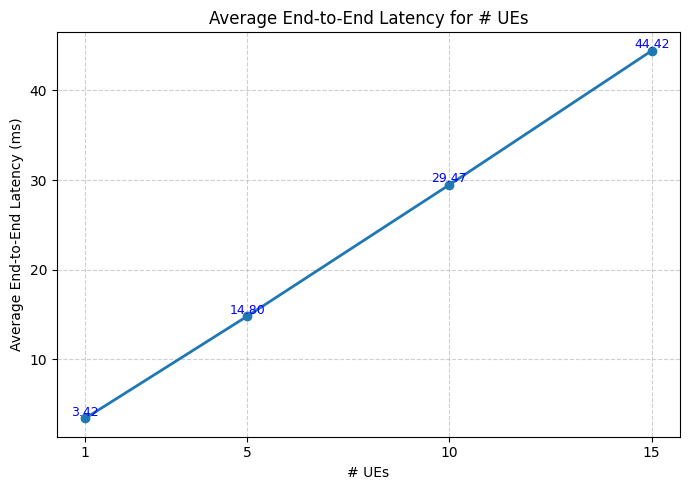

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Load the CSV generated earlier
df = pd.read_csv("/content/ue_end2end_summary.csv")

# Select only specific UE IDs
selected_ues = [1, 5, 10, 15]
subset = df[df["UE"].isin(selected_ues)]

# Sort by UE (to ensure the line plot is ordered)
subset = subset.sort_values(by="UE")

# Plot
plt.figure(figsize=(7, 5))
plt.plot(subset["UE"], subset["Avg_ms"], marker="o", linewidth=2)

# Add labels and formatting
plt.title("Average End-to-End Latency for # UEs")
plt.xlabel("# UEs")
plt.ylabel("Average End-to-End Latency (ms)")
plt.xticks(selected_ues)
plt.grid(True, linestyle="--", alpha=0.6)

# Annotate each point with its Avg(ms)
for _, row in subset.iterrows():
    plt.text(row["UE"], row["Avg_ms"] + 0.3, f"{row['Avg_ms']:.2f}",
             ha="center", fontsize=9, color="blue")

plt.tight_layout()
plt.show()


In [ ]:
s = "2025-11-19T09:05:59.185925,1763543159185,1,0,1.0,0,0,0,0,0,0,0,0,0.16441999999999998,0,0,0,0,0,0,0.16441999999999998,0,0,0,0,0,0,0,0,0,0,0"
for i, j in enumerate(s.split(",")):
  print(f"{i}: {j}")

0: 2025-11-19T09:05:59.185925
1: 1763543159185
2: 1
3: 0
4: 1.0
5: 0
6: 0
7: 0
8: 0
9: 0
10: 0
11: 0
12: 0
13: 0.16441999999999998
14: 0
15: 0
16: 0
17: 0
18: 0
19: 0
20: 0.16441999999999998
21: 0
22: 0
23: 0
24: 0
25: 0
26: 0
27: 0
28: 0
29: 0
30: 0
31: 0


In [ ]:
import numpy as np

arr = np.zeros((1, 17), dtype=float)
arr1 = np.array([arr]).reshape((1, 17))

In [ ]:
!pip install scapy

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.4/2.4 MB 28.8 MB/s eta 0:00:00


In [ ]:
# save as make_pcap_from_csv.py
from scapy.all import Ether, IP, UDP, TCP, Raw, wrpcap
import csv
import ipaddress
import sys

CSV_FILE = "/content/mmtc.csv"   # replace with your CSV filename
OUTPUT_PCAP = "mmtc.pcap"

def ip_to_pseudo_mac(ip_str):
    """Create a reproducible, locally-administered MAC from an IPv4 string.
       Result format: 02:00:xx:xx:xx:xx where xx are the 4 IP octets in hex.
    """
    octets = [int(x) for x in ipaddress.IPv4Address(ip_str).exploded.split('.')]
    return "02:00:%02x:%02x:%02x:%02x" % tuple(octets)

def build_packet(src_ip, dst_ip, proto, size):
    src_mac = ip_to_pseudo_mac(src_ip)
    dst_mac = ip_to_pseudo_mac(dst_ip)

    eth = Ether(src=src_mac, dst=dst_mac)
    ip = IP(src=src_ip, dst=dst_ip)

    proto_up = proto.strip().upper()
    if proto_up == "TCP":
        l4 = TCP(sport=12345, dport=443, flags="A")  # flags A to avoid raw SYN-only flows; tweak as needed
    elif proto_up == "UDP" or proto_up == "DNS":
        l4 = UDP(sport=12345, dport=53 if proto_up=="DNS" else 9999)
    else:
        # fallback: UDP
        l4 = UDP(sport=12345, dport=9999)

    pkt = eth / ip / l4

    # pad so that len(pkt) == desired size (size is total frame length on wire)
    cur_len = len(pkt)
    if size < cur_len:
        # can't shrink packet; warn and leave it as-is
        print(f"WARNING: desired size {size} < built packet size {cur_len}. Packet will be {cur_len}.", file=sys.stderr)
        return pkt
    pad_len = size - cur_len
    if pad_len > 0:
        pkt = pkt / Raw(b"\x00" * pad_len)

    return pkt

packets = []
with open(CSV_FILE, newline='') as csvfile:
    reader = csv.DictReader(csvfile)
    # Accept columns like: Source, Target, Protocol, Size, Time (Time optional)
    for row in reader:
        src = row.get("Source") or row.get("source")
        dst = row.get("Target") or row.get("Destination") or row.get("target") or row.get("destination")
        proto = row.get("Protocol") or row.get("protocol") or "UDP"
        size_field = row.get("Size") or row.get("Length") or row.get("length")
        time_field = row.get("Time") or row.get("time") or None

        if not src or not dst or not size_field:
            print("Skipping row missing Source/Target/Size:", row, file=sys.stderr)
            continue

        try:
            size = int(size_field)
        except ValueError:
            print("Invalid size, skipping row:", row, file=sys.stderr)
            continue

        pkt = build_packet(src, dst, proto, size)
        if time_field:
            try:
                pkt.time = float(time_field)
            except ValueError:
                # ignore if time isn't numeric
                pass
        packets.append(pkt)

if not packets:
    print("No packets created. Check CSV content/columns.", file=sys.stderr)
else:
    wrpcap(OUTPUT_PCAP, packets)
    print(f"Wrote {len(packets)} packets to {OUTPUT_PCAP}")


Wrote 18790 packets to mmtc.pcap
